In [1]:
import scanpy as sc
import pandas as pd
from scipy.io import mmread
import os

os.chdir('c:\\Users\\ankit\\Documents\\scFM\\train_data\\GSE270488_processed') 

In [42]:
X = mmread("human_normalized_rna_matrix.mtx.gz").tocsr()
genes = pd.read_csv("human_normalized_rna_features.tsv.gz", sep="\t", header=None)
barcodes = pd.read_csv("human_cell_barcodes.tsv.gz", sep="\t", header=None)
meta = pd.read_csv("human_metadata.tsv.gz", sep="\t")

adata = sc.AnnData(X.T)
adata.var_names = genes.iloc[:, 0].astype(str)
adata.obs_names = barcodes.iloc[:, 0].astype(str)

# Set barcode column name appropriately
meta = meta.set_index(meta.columns[0])
adata.obs = adata.obs.join(meta, how="left")


In [43]:
adata.X

<Compressed Sparse Column sparse matrix of dtype 'float64'
	with 85155459 stored elements and shape (51624, 36601)>

In [44]:
print("Unique values in 'sample' column:")
print(adata.obs['sample'].unique())

print("\nUnique values in 'disease' column:")
print(adata.obs['disease'].unique())

Unique values in 'sample' column:
['PBMC_1' 'PBMC_2' 'PBMC_3' 'PBMC_4' 'ND_1' 'ND_2' 'ALD_1' 'ALD_2' 'ALD_3'
 'MASH_1' 'MASH_2a' 'MASH_2b']

Unique values in 'disease' column:
['PBMC' 'ND' 'ALD' 'MASH']


In [45]:
keep = [
    "ND",
    "MASH",
]

adata = adata[adata.obs["disease"].isin(keep)].copy()

In [46]:
print(adata)

print("Unique values in 'sample' column:")
print(adata.obs['sample'].unique())

print("\nUnique values in 'disease' column:")
print(adata.obs['disease'].unique())

AnnData object with n_obs × n_vars = 18384 × 36601
    obs: 'sample', 'disease', 'organ', 'sequencing_origin', 'CTgene', 'CTnt', 'CTaa', 'CTstrict', 'Frequency', 'cloneType', 'sct_clusters', 'expansion', 'cellcall'
Unique values in 'sample' column:
['ND_1' 'ND_2' 'MASH_1' 'MASH_2a' 'MASH_2b']

Unique values in 'disease' column:
['ND' 'MASH']


In [47]:
# Add Sample Metadata from Paper

# Define per-sample metadata
sample_meta = pd.DataFrame({
    "sample": ["ALD_1", "ALD_2", "ALD_3", "MASH_1", "MASH_2a", "MASH_2b", "ND_1", "ND_2"],
    "age":    [58,      38,      61,       58,       49,        49,        97,     35],
    "gender": ["F",     "F",     "F",      "M",      "F",       "F",       "M",    "F"],
    "etiology":         ["ALD",  "ALD",   "ALD",    "MASH",   "MASH",    "MASH",  "N/A",  "N/A"],
    "race_ethnicity":   ["White","White", "Hispanic","White", "White",   "White", "White","White"],
    "diabetes":         ["No",   "No",    "No",     "No",     "Yes",     "Yes",   None,   None],
    "bmi":              [21.43,  29.72,   21.87,    23.95,    30.27,     30.27,   None,   None],
    "htn":              ["No",   "No",    "No",     "Yes",    "Yes",     "Yes",   None,   None],
    "hypothyroidism":   ["No",   "No",    "No",     "Yes",    "Yes",     "Yes",   None,   None],
    "osa":              ["No",   "Yes",   "No",     "Yes",    "No",      "No",    None,   None],
    "hyperlipidemia":   ["No",   "No",    "No",     "No",     "Yes",     "Yes",   None,   None],
    "cad":              ["No",   "No",    "Yes; non-obstructive", "No", "No", "No", None, None],
    "bariatric_surgery":["No",   "No",    "No",     "Gastric sleeve", "No", "No", None,  None],
    "sobriety_duration":["60+ months", "11 months", "19 months", "N/A", "N/A", "N/A", None, None],
    "meld_na":          [22,     24,      20,       10,       11,        11,      None,   None],
    "meld_3":           [22,     24,      20,       10,       12,        12,      None,   None],
}).set_index("sample")

# Map metadata onto adata.obs using the existing 'sample' column
new_cols = sample_meta.columns.tolist()
adata.obs = adata.obs.join(sample_meta, on="sample", how="left")

print(adata.obs[["sample", "disease"] + new_cols].drop_duplicates("sample"))

                                  sample disease  age gender etiology  \
ND_1_ND_AAACGGGTCATCGATG-1          ND_1      ND   97      M      N/A   
ND_2_ND_AAACCTGGTACCGAGA-1          ND_2      ND   35      F      N/A   
MASH_1_MASH_AAACCTGAGAATTCCC-1    MASH_1    MASH   58      M     MASH   
MASH_2a_MASH_AAACCTGAGAATGTGT-1  MASH_2a    MASH   49      F     MASH   
MASH_2b_MASH_AAACCTGCACAAGTAA-1  MASH_2b    MASH   49      F     MASH   

                                race_ethnicity diabetes    bmi   htn  \
ND_1_ND_AAACGGGTCATCGATG-1               White     None    NaN  None   
ND_2_ND_AAACCTGGTACCGAGA-1               White     None    NaN  None   
MASH_1_MASH_AAACCTGAGAATTCCC-1           White       No  23.95   Yes   
MASH_2a_MASH_AAACCTGAGAATGTGT-1          White      Yes  30.27   Yes   
MASH_2b_MASH_AAACCTGCACAAGTAA-1          White      Yes  30.27   Yes   

                                hypothyroidism   osa hyperlipidemia   cad  \
ND_1_ND_AAACGGGTCATCGATG-1                None  Non

In [48]:
adata.obs.keys()

Index(['sample', 'disease', 'organ', 'sequencing_origin', 'CTgene', 'CTnt',
       'CTaa', 'CTstrict', 'Frequency', 'cloneType', 'sct_clusters',
       'expansion', 'cellcall', 'age', 'gender', 'etiology', 'race_ethnicity',
       'diabetes', 'bmi', 'htn', 'hypothyroidism', 'osa', 'hyperlipidemia',
       'cad', 'bariatric_surgery', 'sobriety_duration', 'meld_na', 'meld_3'],
      dtype='object')

In [49]:
#Rename MASH to MASH w Cirrhosis
adata.obs['disease'] = adata.obs['disease'].replace({'MASH': 'MASH w Cirrhosis'})

#Print the updated unique values in 'disease' column
print("\nUpdated unique values in 'disease' column:")
print(adata.obs['disease'].unique())


Updated unique values in 'disease' column:
['ND' 'MASH w Cirrhosis']


In [50]:
# Add a assay_type column to adata.obs
adata.obs['assay_type'] = 'scRNA-seq'

In [51]:
# Save the processed AnnData object for future use
adata.write("GSE270488_processed.h5ad")

In [2]:
# Read the saved AnnData object to verify
adata = sc.read_h5ad("GSE270488_processed.h5ad")

In [3]:
print(adata)

AnnData object with n_obs × n_vars = 18384 × 36601
    obs: 'sample', 'disease', 'organ', 'sequencing_origin', 'CTgene', 'CTnt', 'CTaa', 'CTstrict', 'Frequency', 'cloneType', 'sct_clusters', 'expansion', 'cellcall', 'age', 'gender', 'etiology', 'race_ethnicity', 'diabetes', 'bmi', 'htn', 'hypothyroidism', 'osa', 'hyperlipidemia', 'cad', 'bariatric_surgery', 'sobriety_duration', 'meld_na', 'meld_3', 'assay_type'


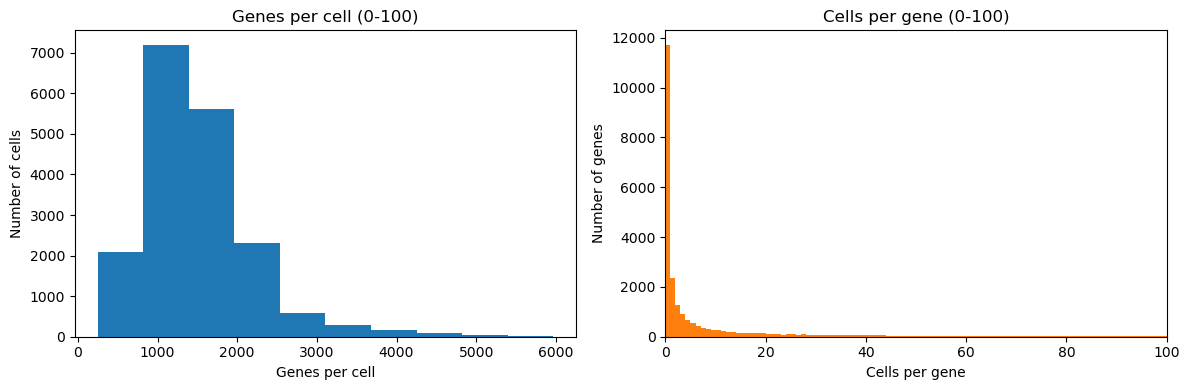

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import sparse

X = adata.X

if sparse.issparse(X):
    X = X.tocsc()
    genes_per_cell = np.asarray((X > 0).sum(axis=1)).ravel()
    cells_per_gene = np.asarray((X > 0).sum(axis=0)).ravel()
else:
    genes_per_cell = np.sum(X > 0, axis=1)
    cells_per_gene = np.sum(X > 0, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(genes_per_cell)#, bins=np.arange(0, 102), color="C0")#,=(0, 100))
#axes[0].set_xlim(0, 100)
axes[0].set_xlabel("Genes per cell")
axes[0].set_ylabel("Number of cells")
axes[0].set_title("Genes per cell (0-100)")

axes[1].hist(cells_per_gene, bins=np.arange(0, 102), range=(0, 100), color="C1")
axes[1].set_xlim(0, 100)
axes[1].set_xlabel("Cells per gene")
axes[1].set_ylabel("Number of genes")
axes[1].set_title("Cells per gene (0-100)")

plt.tight_layout()
plt.show()

In [5]:
# Determine the minimum and maximum number of genes per cell
min_genes_per_cell = np.min(genes_per_cell)
print(f"Minimum number of genes per cell: {min_genes_per_cell}")
# Determine how many cells have at least the minimum number of genes
num_cells_with_min_genes = np.sum(genes_per_cell >= min_genes_per_cell)
print(f"Number of cells with at least {min_genes_per_cell} genes: {num_cells_with_min_genes}")

Minimum number of genes per cell: 247
Number of cells with at least 247 genes: 18384


In [54]:
# View sample of adata transcriptomic data
print(adata.X[:100, :100])

# View assay type column head
print(adata.obs['assay_type'].head())

<Compressed Sparse Column sparse matrix of dtype 'float64'
	with 370 stored elements and shape (100, 100)>
  Coords	Values
  (27, 6)	1.6668635681486232
  (69, 16)	1.6037026728803543
  (72, 16)	1.247431518155778
  (74, 16)	1.1829473332153773
  (75, 16)	0.9894519904056397
  (11, 17)	0.9017513483943169
  (54, 17)	1.1497797211260308
  (65, 17)	1.497885426528353
  (73, 17)	1.2376148999277883
  (5, 24)	0.6847541419056519
  (9, 24)	1.039624048151085
  (11, 24)	0.9017513483943169
  (23, 24)	1.0850647975023702
  (31, 24)	0.8108607780405805
  (37, 24)	0.8344778928487593
  (40, 24)	2.018551708457756
  (47, 24)	1.8047941742342448
  (50, 24)	1.5379356293417232
  (53, 24)	1.04712754119977
  (62, 24)	0.7411838598262165
  (66, 24)	1.1277032533786588
  (71, 24)	2.1015394369183102
  (85, 24)	1.6682587417447567
  (92, 24)	2.0547691313352106
  (95, 24)	1.1848351091483489
  :	:
  (11, 97)	0.9017513483943169
  (13, 97)	0.9168911521863988
  (17, 97)	1.9249492734632614
  (19, 97)	1.2890957308953186
  (23, 97)